In [57]:
import os
import joblib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    RocCurveDisplay,

)

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import mlflow.catboost

### Data Import

In [58]:
PROJECT_ROOT = Path("../")

DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "features" /
    "customer_churn_dataset.csv"
)


customers_ml = pd.read_csv(DATA_PATH)

customers_ml.head()

,frequency,monetary,avg_order_value,unique_categories,unique_sellers,avg_review_score,late_delivery_ratio,avg_installments,max_installments,payment_method_count,preferred_payment_type,state,latitude,longitude,churn_label
0,2,82.82,41.41,2,2,4.5,0.0,1.0,1.0,1,credit_card,SP,-23.577482,-46.587077,1
1,1,141.46,141.46,1,1,4.0,0.0,1.0,1.0,1,boleto,BA,-12.186877,-44.540232,0
2,1,179.12,179.12,1,1,5.0,0.0,3.0,3.0,1,credit_card,GO,-16.745150,-48.514783,0
3,1,72.20,72.20,1,1,5.0,0.0,1.0,1.0,1,credit_card,RN,-5.774002,-35.270976,1
4,1,28.62,28.62,1,1,5.0,0.0,1.0,1.0,1,credit_card,SP,-23.676257,-46.514580,1


In [59]:
customers_ml.shape

(96096, 15)

### Train Test Split

In [60]:
X = customers_ml.drop(columns=["churn_label"])

y = customers_ml["churn_label"]

In [61]:
X.value_counts()

frequency  monetary  avg_order_value  unique_categories  unique_sellers  avg_review_score  late_delivery_ratio  avg_installments  max_installments  payment_method_count  preferred_payment_type  state  latitude    longitude 
1          82.98     82.980000        1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             SP     -23.604706  -46.693332    3
           42.27     42.270000        1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             RN     -5.887088   -35.207494    3
           65.00     65.000000        1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             PR     -25.434017  -49.297219    2
           0.00      0.000000         0                  0               1.000000        

In [62]:
y.value_counts()

churn_label
1    64212
0    31884
Name: count, dtype: int64

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (76876, 14)
Test set shape: (19220, 14)


### Create Shared Preprocessing Components
- Uses **SimpleImputer** library

In [65]:
print("Categorical features:")
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()
print(categorical_features)

print("\nNumerical features:")
numeric_features = X.select_dtypes(
    exclude="object"
).columns.tolist()
print(numeric_features)




Categorical features:
['preferred_payment_type', 'state']

Numerical features:
['frequency', 'monetary', 'avg_order_value', 'unique_categories', 'unique_sellers', 'avg_review_score', 'late_delivery_ratio', 'avg_installments', 'max_installments', 'payment_method_count', 'latitude', 'longitude']


#### Numerical Imputation

In [66]:
# Missing value imputation for numerical features
numeric_imputer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"  # Use median
            )
        )
    ]
)

#### Categorical One-Hot Encoding

In [67]:
# Missing value imputation for categorical features
categorical_encoder = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"   # Use mode
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"   # Ignore unknown categories during transformation when deployment
            )
        )
    ]
)

In [68]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_imputer,
            numeric_features
        ),
        (
            "categorical",
            categorical_encoder,
            categorical_features
        )
    ],
    remainder="drop"
)

In [69]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (76876, 46)
Processed testing shape: (19220, 46)


### Model Evaluation Function

In [70]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)  # Returns the final class

    probabilities = model.predict_proba(X_test)[:, 1]  # Returns probabilities for the 
                                                       # positive class (churn)

    metrics = {
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "precision": precision_score(
            y_test,
            predictions
        ),

        "recall": recall_score(
            y_test,
            predictions
        ),

        "f1_score": f1_score(
            y_test,
            predictions
        ),

        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        )
    }

    return metrics

### Cross-Validation Strategy

In [71]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### MLFlow Setup

In [72]:
PROJECT_ROOT = Path("../").resolve()

mlflow.set_tracking_uri(
    f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}"
)

mlflow.set_experiment("E-Commerce_Cust_Churn_Tuning")

print("MLflow Tracking URI:", mlflow.get_tracking_uri())

MLflow Tracking URI: sqlite:///C:\Users\cjc72\Desktop\e-commerce-ai-ml-retention-platform\e-commerce-ai-ml-retention-platform\mlflow.db


### Model Tuning

- For scoring metrics we choose F1-macro because it balances between Precision/recall, and average equally across both classes
#### LightGBM

In [ ]:
# Define base model
lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Define pipeline
lgbm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            lgbm
        )
    ]
)

# Define search space
lgbm_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 5, 10, 15],
    "model__min_child_samples": [10, 20, 30, 50, 100],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"]
}

In [74]:
with mlflow.start_run(run_name="lightgbm_tuning") as run:
    search_lgbm = RandomizedSearchCV(
        estimator=lgbm_pipeline,
        param_distributions=lgbm_param_grid,
        n_iter=30,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    search_lgbm.fit(X_train, y_train)

    best_lgbm = search_lgbm.best_estimator_

    test_metrics = evaluate_model(
        best_lgbm,
        X_test,
        y_test
    )

    mlflow.log_params(search_lgbm.best_params_)
    mlflow.log_metric("cv_best_f1", search_lgbm.best_score_)

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(
            f"test_{metric_name}",
            metric_value
        )

    mlflow.sklearn.log_model(
        best_lgbm,
        "model",
        serialization_format="pickle"
    )

    print("Best LightGBM parameters:")
    print(search_lgbm.best_params_)

    print("\nBest cross-validation F1:")
    print(search_lgbm.best_score_)


    print("\nTest metrics:")
    print(test_metrics)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/08/12 13:51:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 13:51:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best LightGBM parameters:
{'model__subsample': 0.7, 'model__reg_lambda': 0.1, 'model__reg_alpha': 0.01, 'model__num_leaves': 31, 'model__n_estimators': 500, 'model__min_child_samples': 100, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8, 'model__class_weight': 'balanced'}

Best cross-validation F1:
0.5783997304689038

Test metrics:
{'accuracy': 0.5859521331945889, 'precision': 0.7412822285883631, 'recall': 0.5842871603207973, 'f1_score': 0.6534877645214665, 'roc_auc': 0.6271915816753227}


#### CatBoost

In [80]:
# Define base model
catboost = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

# Define pipeline
catboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            catboost
        )
    ]
)

# Define search space
catboost_param_grid = {
    "model__iterations": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__depth": [4, 5, 6, 7, 8, 10],
    "model__l2_leaf_reg": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__auto_class_weights": ['Balanced']
}

In [81]:
with mlflow.start_run(run_name="catboost_tuning") as run:
    search_catboost = RandomizedSearchCV(
        estimator=catboost_pipeline,
        param_distributions=catboost_param_grid,
        n_iter=30,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    search_catboost.fit(X_train, y_train)

    best_catboost = search_catboost.best_estimator_

    test_metrics = evaluate_model(
        best_catboost,
        X_test,
        y_test
    )

    mlflow.log_params(search_catboost.best_params_)
    mlflow.log_metric(
        "cv_best_f1",
        search_catboost.best_score_
    )

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(
            f"test_{metric_name}",
            metric_value
        )

    mlflow.sklearn.log_model(
        best_catboost,
        "model",
        serialization_format="pickle"
    )

    print("Best CatBoost parameters:")
    print(search_catboost.best_params_)

    print("\nBest cross-validation F1:")
    print(search_catboost.best_score_)

    print("\nTest metrics:")
    print(test_metrics)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/08/12 14:15:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 14:15:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best CatBoost parameters:
{'model__subsample': 1.0, 'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 10, 'model__auto_class_weights': 'Balanced'}

Best cross-validation F1:
0.5718914302021003

Test metrics:
{'accuracy': 0.5840270551508845, 'precision': 0.7361192285213326, 'recall': 0.5884139219808456, 'f1_score': 0.6540308970530962, 'roc_auc': 0.6141504587843309}


#### Random Forest

In [82]:
# Define base model
random_forest = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Define pipeline
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            random_forest
        )
    ]
)

# Define search space
rf_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": ["balanced"]
}

In [83]:
with mlflow.start_run(run_name="random_forest_tuning") as run:
    search_rf = RandomizedSearchCV(
        estimator=rf_pipeline,
        param_distributions=rf_param_grid,
        n_iter=30,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    search_rf.fit(X_train, y_train)

    best_rf = search_rf.best_estimator_

    test_metrics = evaluate_model(
        best_rf,
        X_test,
        y_test
    )

    mlflow.log_params(search_rf.best_params_)
    mlflow.log_metric(
        "cv_best_f1",
        search_rf.best_score_
    )

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(
            f"test_{metric_name}",
            metric_value
        )

    mlflow.sklearn.log_model(
        best_rf,
        "model",
        serialization_format="pickle"
    )

    print("Best Random Forest parameters:")
    print(search_rf.best_params_)

    print("\nBest cross-validation F1:")
    print(search_rf.best_score_)

    print("\nTest metrics:")
    print(test_metrics)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/08/12 14:53:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 14:53:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Random Forest parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 30, 'model__class_weight': 'balanced'}

Best cross-validation F1:
0.5960036748674953

Test metrics:
{'accuracy': 0.6307492195629553, 'precision': 0.7454296941739279, 'recall': 0.6794362687845519, 'f1_score': 0.7109047211699051, 'roc_auc': 0.6585350972299557}


### Tuned Model Comparison

In [97]:
tuned_models = {
    "LightGBM": best_lgbm,
    "CatBoost": best_catboost,
    "Random Forest": best_rf
}

tuned_results = []

for model_name, model in tuned_models.items():
    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["model"] = model_name
    tuned_results.append(metrics)

tuned_results = pd.DataFrame(tuned_results)

tuned_results = tuned_results[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]
].sort_values(
    "f1_score",
    ascending=False
)

tuned_results

,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.630749,0.745430,0.679436,0.710905,0.658535
1,CatBoost,0.584027,0.736119,0.588414,0.654031,0.614150
0,LightGBM,0.585952,0.741282,0.584287,0.653488,0.627192


### Base vs Tuned

In [98]:
baseline_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": 0.542924037,
        "f1_score": 0.540509440,
        "precision": 0.509064039,
        "recall": 0.576095439,
        "roc_auc": 0.567307237
    },
    {
        "model": "Random Forest",
        "accuracy": 0.556399583,
        "f1_score": 0.521870794,
        "precision": 0.524991537,
        "recall": 0.518786932,
        "roc_auc": 0.580511527
    },
    {
        "model": "LightGBM",
        "accuracy": 0.584131113,
        "f1_score": 0.564912089,
        "precision": 0.551903850,
        "recall": 0.578548333,
        "roc_auc": 0.616755510
    },
    {
        "model": "CatBoost",
        "accuracy": 0.568158168,
        "f1_score": 0.552801724,
        "precision": 0.534876446,
        "recall": 0.571970119,
        "roc_auc": 0.598292725
    }
])

baseline_results["stage"] = "Baseline"
tuned_results["stage"] = "Tuned"

comparison_results = pd.concat(
    [baseline_results, tuned_results],
    ignore_index=True
)

comparison_results = comparison_results[
    [
        "stage",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]
]

comparison_results.sort_values(
    ["f1_score", "roc_auc"],
    ascending=False
)

,stage,model,accuracy,precision,recall,f1_score,roc_auc
4,Tuned,Random Forest,0.630749,0.745430,0.679436,0.710905,0.658535
5,Tuned,CatBoost,0.584027,0.736119,0.588414,0.654031,0.614150
6,Tuned,LightGBM,0.585952,0.741282,0.584287,0.653488,0.627192
2,Baseline,LightGBM,0.584131,0.551904,0.578548,0.564912,0.616756
3,Baseline,CatBoost,0.568158,0.534876,0.571970,0.552802,0.598293
0,Baseline,Logistic Regression,0.542924,0.509064,0.576095,0.540509,0.567307
1,Baseline,Random Forest,0.556400,0.524992,0.518787,0.521871,0.580512


### Model Performance Visualization

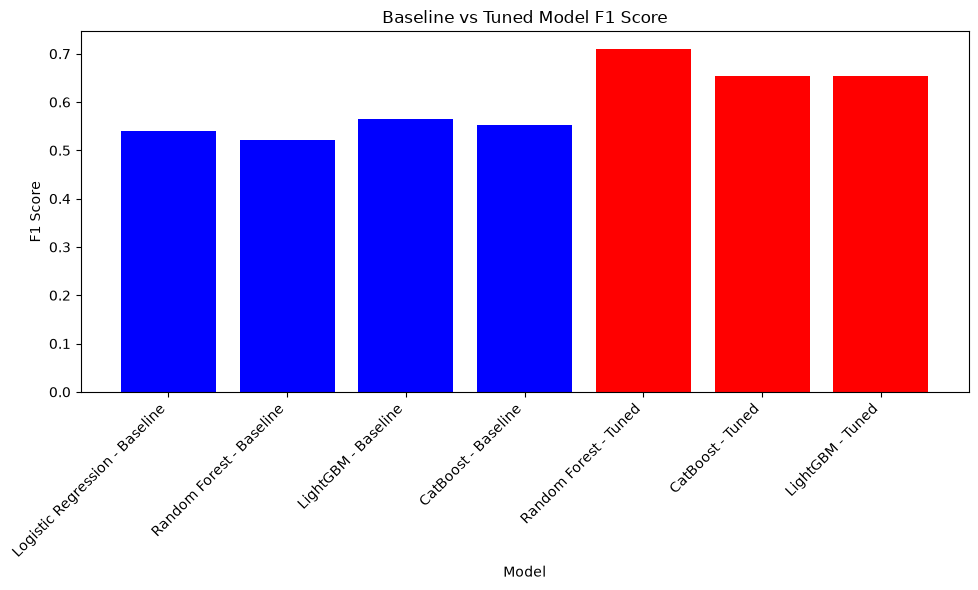

In [99]:
plt.figure(figsize=(10, 6))

comparison_results["label"] = (
    comparison_results["model"]
    + " - "
    + comparison_results["stage"]
)

colors = comparison_results["stage"].map({
    "Baseline": "blue",
    "Tuned": "red"
})

plt.bar(
    comparison_results["label"],
    comparison_results["f1_score"],
    color=colors
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Baseline vs Tuned Model F1 Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

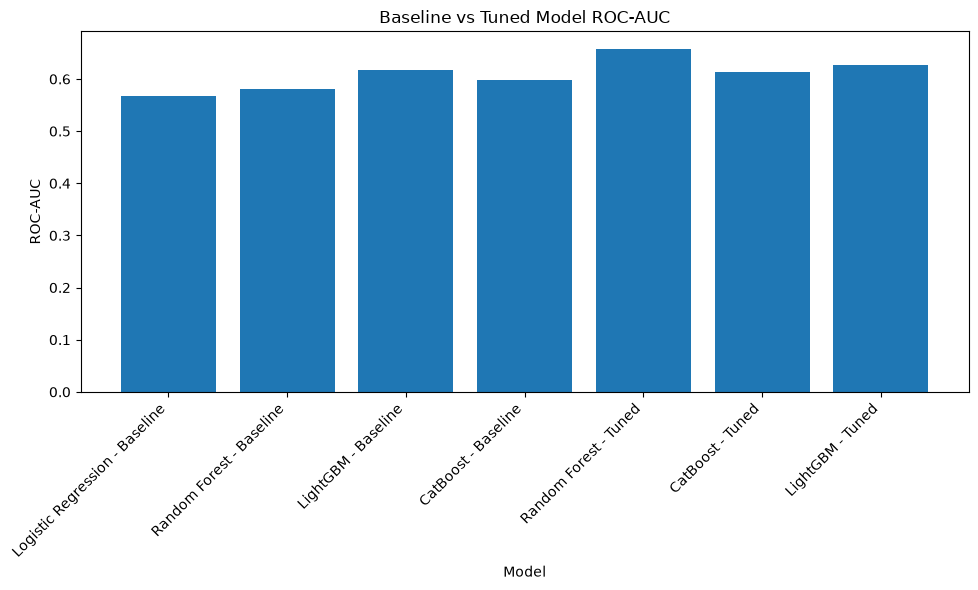

In [100]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_results["label"],
    comparison_results["roc_auc"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Baseline vs Tuned Model ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Best Model Selection

In [101]:
best_model_row = comparison_results.sort_values(
    ["f1_score", "roc_auc"],
    ascending=False
).iloc[0]

print("Best model:")
print(best_model_row)

best_model_name = best_model_row["model"]
best_model_stage = best_model_row["stage"]

print("Model:", best_model_name)
print("Stage:", best_model_stage)
print("F1:", best_model_row["f1_score"])
print("ROC-AUC:", best_model_row["roc_auc"])

Best model:
stage                        Tuned
model                Random Forest
accuracy                  0.630749
precision                  0.74543
recall                    0.679436
f1_score                  0.710905
roc_auc                   0.658535
label        Random Forest - Tuned
Name: 4, dtype: object
Model: Random Forest
Stage: Tuned
F1: 0.7109047211699051
ROC-AUC: 0.6585350972299557


In [102]:
# Explicitly select the overall winner based on the comparison table
best_model_name = tuned_results.iloc[0]["model"]

best_model = tuned_models[best_model_name]

print(f"Selected best model: {best_model_name}")
print(best_model)

Selected best model: Random Forest
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['frequency', 'monetary',
                                                   'avg_order_value',
                                                   'unique_categories',
                                                   'unique_sellers',
                                                   'avg_review_score',
                                                   'late_delivery_ratio',
                                                   'avg_installments',
                                                   'max_installments',
                                                   'payment_method_count',
                                        

### Final Model Evaluation

In [103]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
print(y_pred)
print(y_prob)

[1 0 0 ... 0 1 1]
[0.55002572 0.38223458 0.23364224 ... 0.45190963 0.66563567 0.89131323]


In [104]:
final_metrics = evaluate_model(
    best_model,
    X_test,
    y_test
)

print("Final Model:", best_model_name)

for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Final Model: Random Forest
accuracy: 0.6307
precision: 0.7454
recall: 0.6794
f1_score: 0.7109
roc_auc: 0.6585


In [105]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

   Not Churn       0.45      0.53      0.49      6377
       Churn       0.75      0.68      0.71     12843

    accuracy                           0.63     19220
   macro avg       0.60      0.61      0.60     19220
weighted avg       0.65      0.63      0.64     19220



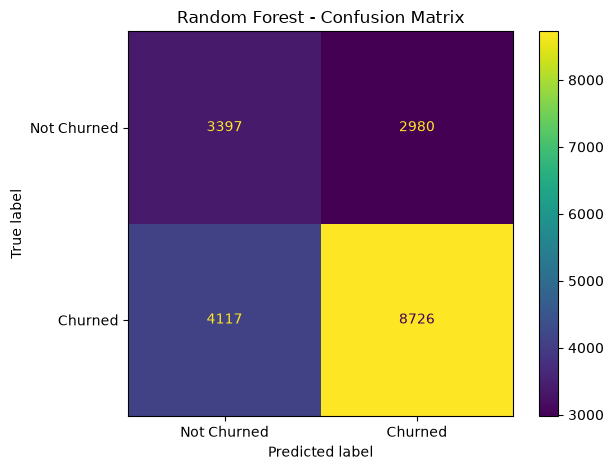

In [106]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churned", "Churned"]
)

disp.plot()
plt.title(f"{best_model_name} - Confusion Matrix")
plt.tight_layout()
plt.show()

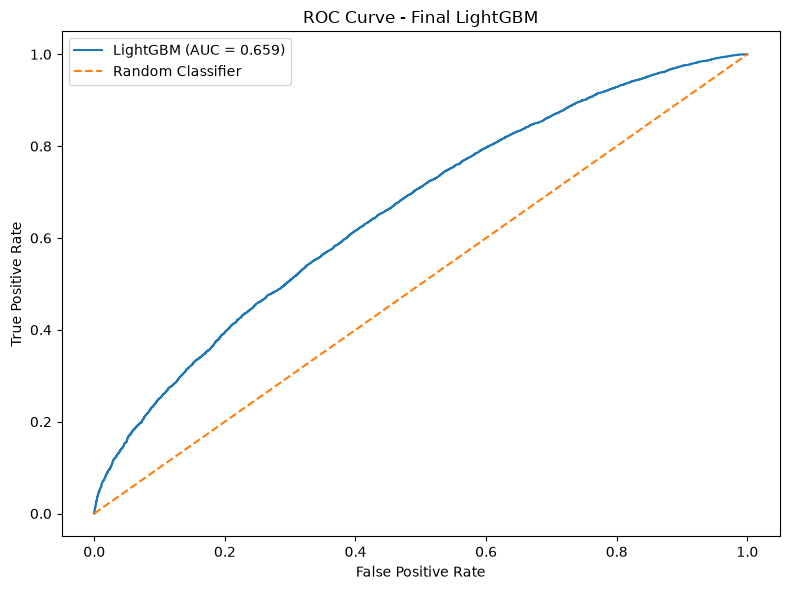

In [107]:
from sklearn.metrics import roc_curve


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM (AUC = {final_metrics['roc_auc']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final LightGBM")
plt.legend()
plt.tight_layout()
plt.show()

In [108]:
with mlflow.start_run(run_name="final_model_evaluation"):
    mlflow.log_param(
        "model_type",
        best_model_name
    )

    mlflow.log_param(
        "selection_metric",
        "f1_score"
    )

    mlflow.log_param(
        "secondary_metric",
        "roc_auc"
    )

    for metric_name, metric_value in final_metrics.items():
        mlflow.log_metric(
            metric_name,
            metric_value
        )

    mlflow.sklearn.log_model(
        best_model,
        "final_model",
        serialization_format="pickle"
    )

    print("Final model evaluation logged to MLflow.")

2026/08/12 15:00:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 15:00:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final model evaluation logged to MLflow.


### Save final model

In [109]:
os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)

print("Model saved to ../models/churn_model.pkl")

Model saved to ../models/churn_model.pkl
